# Understanding Convolutional Neural Network and it´s Implementation for Classification Problem


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Reshape dataset to match model´s expected input shape (28,28,1)
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

C:\Users\sarah\source\repos\UCLan_ArtificialIntelligence\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9546 - loss: 0.1469 - val_accuracy: 0.9841 - val_loss: 0.0484
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9850 - loss: 0.0486 - val_accuracy: 0.9866 - val_loss: 0.0420
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9892 - loss: 0.0345 - val_accuracy: 0.9888 - val_loss: 0.0338
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9919 - loss: 0.0249 - val_accuracy: 0.9837 - val_loss: 0.0512
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9941 - loss: 0.0179 - val_accuracy: 0.9896 - val_loss: 0.0323
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9952 - loss: 0.0146 - val_accuracy: 0.9910 - val_loss: 0.0314
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9961 - loss: 0.0122 - val_accuracy: 0.9903 - val_loss: 0.0311
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9966 - loss: 0

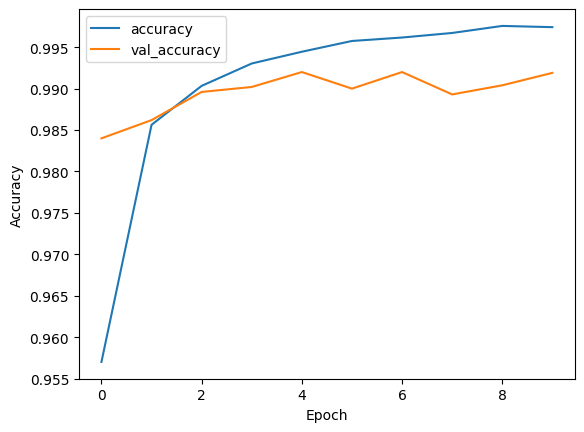

In [6]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


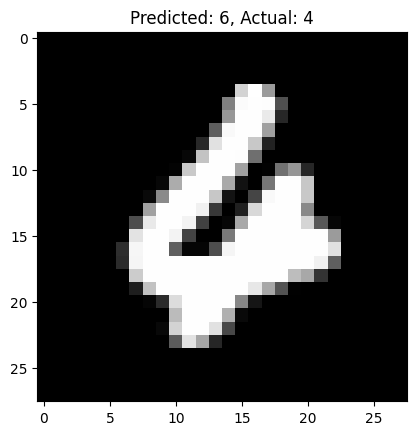

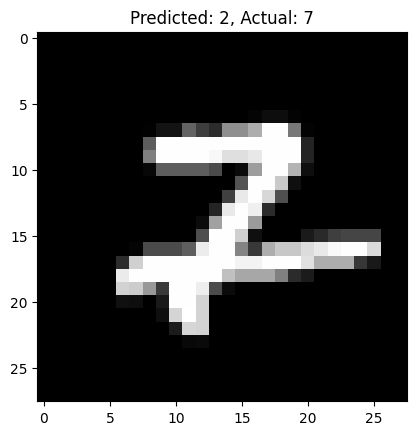

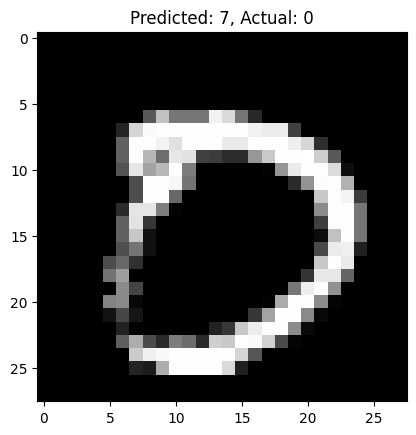

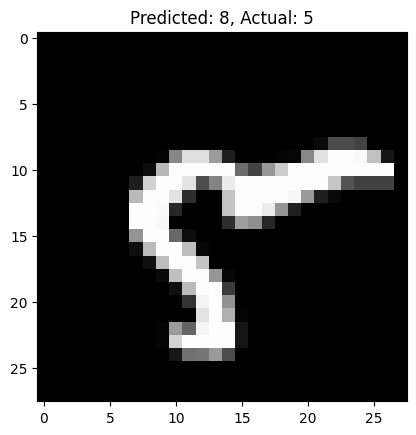

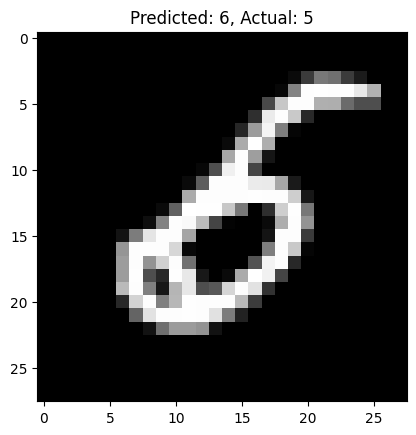

In [7]:
import random
predictions = model.predict(x_test)
misclassified_indices = [i for i in range(len(y_test)) if np.argmax(predictions[i]) != y_test[i]]
random_samples = random.sample(misclassified_indices, 5)

for i in random_samples:
  plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
  plt.title(f"Predicted: {np.argmax(predictions[i])}, Actual: {y_test[i]}")
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


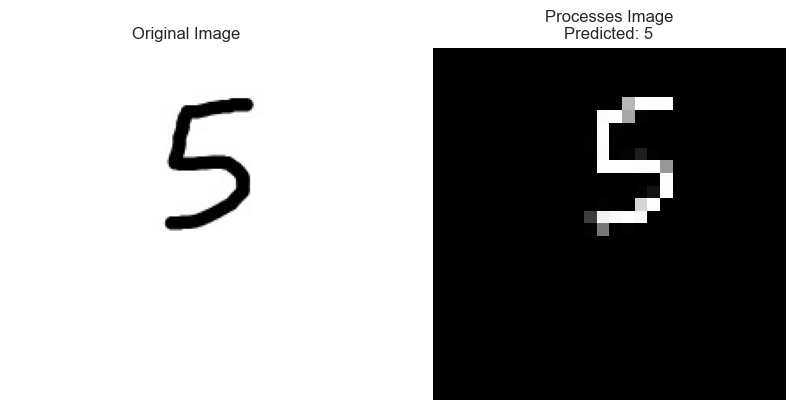

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load the image from file
image_path = "./Test_MNIST/5.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not loaded. Check file path.")
else:
    # Display the original and processed images
    plt.figure(figsize=(10, 5))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    # Resize image to match MNIST dimensions
    image_resized = cv2.resize(image, (28, 28))

    # Invert colors if needed (MNIST is white digits on black background)
    image_resized = 255 - image_resized

    # Normalize and reshape the image
    image_resized = image_resized.astype("float32") / 255.0
    image_resized = image_resized.reshape(1, 28, 28, 1) # Ensure correct input shape

    prediction = model.predict(image_resized)
    predicted_label = np.argmax(prediction)

    # Processed Image
    plt.subplot(1, 2, 2)
    plt.imshow(image_resized.reshape(28, 28), cmap='gray')
    plt.title(f"Processes Image\nPredicted: {predicted_label}")
    plt.axis('off')
    plt.show()